# OKAFF: random features 

Compare $m=500$, $1000$, and $5000$ for `CovDiag(var=0.3)`. ARL uses a logarithmic x-axis; EDD uses a linear y-axis. 

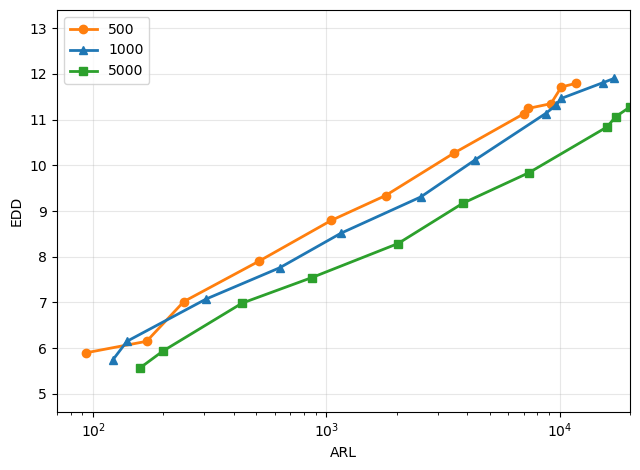

Saved okaff_cov03_edd-d20.pdf


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import LogFormatterMathtext, MaxNLocator
import pandas as pd


CASE_NAME = "CovDiag(var=0.3)"
FEATURE_COUNTS = (500, 1000, 5000)
OUTPUT_PDF = "okaff_cov03_edd-d20.pdf"
STYLES = {
    500: {"marker": "o", "color": "#ff7f0e"},
    1000: {"marker": "^", "color": "#1f77b4"},
    5000: {"marker": "s", "color": "#2ca02c"},
}


def csv_path(directory: Path, features: int) -> Path:
    filename = (
            f"OKAFF-ARL-EDD-d20-m{features}-nrun{n_runs}.csv"
    )
    
    for path in (directory / filename, directory / "AFF" / filename):
        if path.is_file():
            return path
    raise FileNotFoundError(f"Missing {filename} in {directory} or {directory / 'AFF'}")


def load_case(path: Path) -> pd.DataFrame:
    data = pd.read_csv(path).rename(
        columns={"arl_hat_method3": "arl_hat", "edd_hat_method3": "edd_hat"}
    )
    case = data.loc[data["post_change_name"] == CASE_NAME].sort_values("arl_hat")
    if case.empty:
        raise ValueError(f"{CASE_NAME} was not found in {path.name}")
    return case


def plot_okaff(directory: Path = Path(".")) -> Path:
    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    edd_values = []

    for features in FEATURE_COUNTS:
        case = load_case(csv_path(directory, features))
        edd_values.extend(case["edd_hat"].dropna().tolist())
        ax.plot(
            case["arl_hat"],
            case["edd_hat"],
            marker=STYLES[features]["marker"],
            color=STYLES[features]["color"],
            linewidth=2,
            label=str(features),
        )

    ax.set_xscale("log")
    ax.set_xlim(70, 20000)
    ax.set_xticks((100, 1000, 10000))
    ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))

    
    locator = MaxNLocator(nbins=7, integer=True, min_n_ticks=5)
    y_ticks = [
        float(value)
        for value in locator.tick_values(min(edd_values), max(edd_values) * 1.08)
        if value > 0
    ]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{value:g}" for value in y_ticks])
    y_min = min(min(edd_values), min(y_ticks))
    y_max = max(max(edd_values), max(y_ticks))
    padding = 0.05 * max(y_max - y_min, 1)
    ax.set_ylim(y_min - padding, y_max + padding)

    ax.set_xlabel("ARL")
    ax.set_ylabel("EDD")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.tight_layout()
    output = directory / OUTPUT_PDF
    fig.savefig(output, bbox_inches="tight")
    plt.show()
    return output


if __name__ == "__main__":
    print(f"Saved {plot_okaff()}")
